In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# ==========================================================
# Load Recommendation Dataset
# ==========================================================

recommendations = pd.read_csv("datasets/factory_recommendations.csv")

print(recommendations.shape)

recommendations.head()

(5000, 47)


,Order ID,Row ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Predicted Shipping Cost,Predicted Lead Time,Lead Time Improvement,Shipping Cost Savings,Estimated Gross Profit,Profit Impact,Optimization Score,Recommendation,Priority,Scenario Confidence Score
0,ORD00001,1,2025-02-07,2025-02-08,1,CUST9313,USA,Houston,TX,38140,...,277.70,1.002243,-0.0,49.00,-6.80,-277.70,-40.84,Reallocate,Low,75.0
1,ORD00002,2,2025-05-04,2025-05-05,1,CUST3028,USA,Chicago,IL,39260,...,360.91,1.002243,-0.0,63.69,-322.96,-360.91,-53.08,Reallocate,Low,75.0
2,ORD00003,3,2025-04-24,2025-04-25,1,CUST7867,USA,New York,NY,28907,...,283.31,1.002243,-0.0,49.99,-256.60,-283.31,-41.67,Reallocate,Low,75.0
3,ORD00004,4,2025-10-25,2025-10-29,2,CUST2028,USA,Los Angeles,CA,83972,...,266.22,2.997709,1.0,46.98,-129.99,-266.22,-38.65,Reallocate,Medium,80.0
4,ORD00005,5,2025-08-07,2025-08-12,1,CUST6924,USA,Houston,TX,49291,...,2129.00,4.001485,1.0,375.70,-1787.50,-2129.00,-312.59,Reallocate,Medium,80.0


In [3]:
# ==========================================================
# Lead Time Reduction
# ==========================================================

recommendations["Lead Time Reduction (%)"] = (

    recommendations["Lead Time Improvement"]

    / recommendations["Lead Time"]

) * 100

recommendations["Lead Time Reduction (%)"] = recommendations[
    "Lead Time Reduction (%)"
].round(2)

In [4]:
# ==========================================================
# Profit Impact Stability
# ==========================================================

recommendations["Profit Impact Stability"] = np.where(

    recommendations["Profit Impact"] >= 0,

    "Stable",

    "Needs Review"

)

In [5]:
# ==========================================================
# Recommendation Coverage
# ==========================================================

coverage = (

    recommendations["Recommendation"]

    .value_counts(normalize=True)

    * 100

)

coverage

Recommendation
Reallocate    100.0
Name: proportion, dtype: float64

In [6]:
# ==========================================================
# High Risk Reassignments
# ==========================================================

recommendations["Risk Level"] = np.where(

    (recommendations["Profit Impact"] < 0)

    &

    (recommendations["Lead Time Improvement"] <= 0),

    "High Risk",

    "Low Risk"

)

In [7]:
# ==========================================================
# KPI Summary
# ==========================================================

kpi_summary = pd.DataFrame({

    "Metric":[

        "Average Lead Time Reduction (%)",

        "Average Shipping Cost Savings",

        "Average Profit Impact",

        "Recommendation Coverage (%)"

    ],

    "Value":[

        recommendations["Lead Time Reduction (%)"].mean(),

        recommendations["Shipping Cost Savings"].mean(),

        recommendations["Profit Impact"].mean(),

        (recommendations["Recommendation"]=="Reallocate").mean()*100

    ]

})

kpi_summary

,Metric,Value
0,Average Lead Time Reduction (%),7.377620
1,Average Shipping Cost Savings,143.959972
2,Average Profit Impact,-815.775598
3,Recommendation Coverage (%),100.000000


In [8]:
# ==========================================================
# Top 10 Recommendations
# ==========================================================

top10 = recommendations.sort_values(

    by="Optimization Score",

    ascending=False

).head(10)

top10

,Order ID,Row ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Shipping Cost Savings,Estimated Gross Profit,Profit Impact,Optimization Score,Recommendation,Priority,Scenario Confidence Score,Lead Time Reduction (%),Profit Impact Stability,Risk Level
1182,ORD01183,1183,2025-04-18,2025-04-22,3,CUST8282,USA,Chicago,IL,10675,...,6.82,147.54,-38.63,-5.68,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
4653,ORD04654,4654,2025-05-05,2025-05-09,3,CUST8522,USA,Chicago,IL,83356,...,6.88,55.68,-39.02,-5.74,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
3593,ORD03594,3594,2025-12-11,2025-12-15,3,CUST7232,USA,New York,NY,17914,...,6.88,60.32,-39.02,-5.74,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
1625,ORD01626,1626,2025-03-03,2025-03-07,3,CUST8915,USA,Chicago,IL,57383,...,6.95,88.27,-39.40,-5.80,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
2529,ORD02530,2530,2025-08-18,2025-08-22,3,CUST3679,USA,Los Angeles,CA,82881,...,7.02,74.46,-39.78,-5.85,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
2120,ORD02121,2121,2025-06-02,2025-06-06,3,CUST6785,USA,Houston,TX,83999,...,7.36,682.87,-41.69,-6.13,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
2305,ORD02306,2306,2025-11-21,2025-11-25,3,CUST3115,USA,Los Angeles,CA,35947,...,7.49,112.65,-42.46,-6.25,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
4751,ORD04752,4752,2025-09-26,2025-09-30,3,CUST1415,USA,Los Angeles,CA,57071,...,7.70,11.47,-43.60,-6.41,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
3581,ORD03582,3582,2025-01-26,2025-01-30,3,CUST7394,USA,Chicago,IL,49196,...,7.83,21.82,-44.37,-6.52,Reallocate,Low,75.0,-0.0,Needs Review,High Risk
2107,ORD02108,2108,2025-02-12,2025-02-16,3,CUST1144,USA,New York,NY,96294,...,7.90,174.04,-44.75,-6.58,Reallocate,Low,75.0,-0.0,Needs Review,High Risk


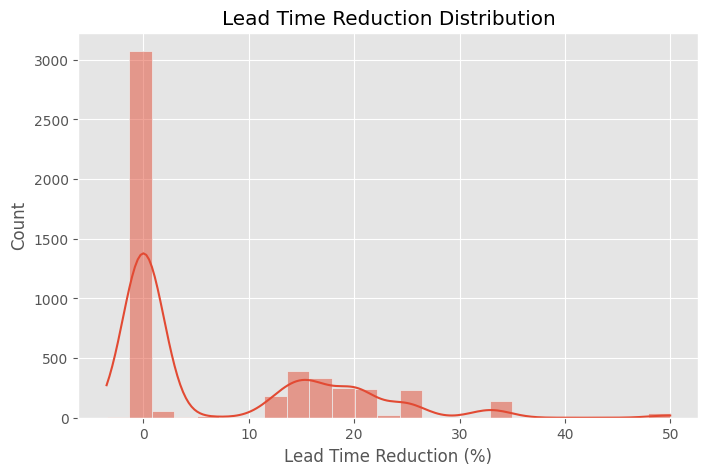

In [9]:
# ==========================================================
# Lead Time Reduction Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(

    recommendations["Lead Time Reduction (%)"],

    bins=25,

    kde=True

)

plt.title("Lead Time Reduction Distribution")

plt.show()

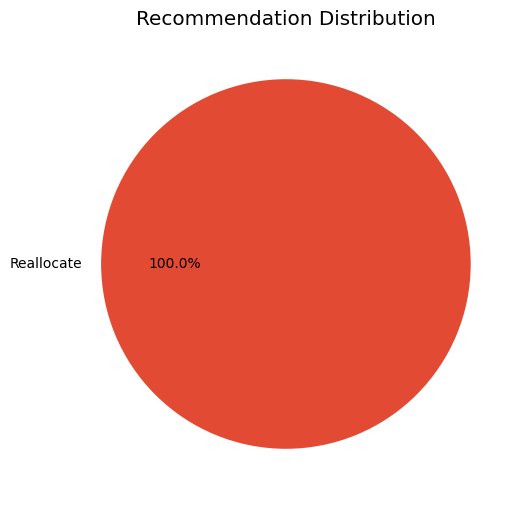

In [10]:
# ==========================================================
# Recommendation Distribution
# ==========================================================

plt.figure(figsize=(6,6))

recommendations["Recommendation"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Recommendation Distribution")

plt.show()

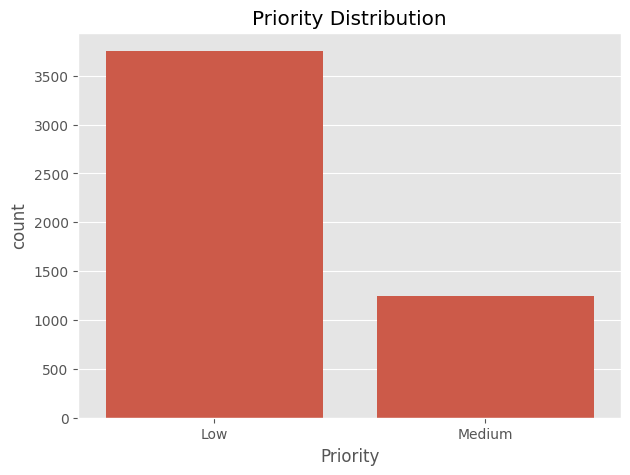

In [11]:
# ==========================================================
# Priority Distribution
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(

    data=recommendations,

    x="Priority"

)

plt.title("Priority Distribution")

plt.show()

In [12]:
# ==========================================================
# Save KPI Summary
# ==========================================================

kpi_summary.to_csv(

    "datasets/kpi_summary.csv",

    index=False

)

print("kpi_summary.csv saved successfully!")

kpi_summary.csv saved successfully!
